In [1]:
import h5py, glob, os, re
import numpy as np
import matplotlib.pyplot as plt

results_root = os.path.expanduser('~/ParaToric/results')
t_files = sorted(glob.glob(f'{results_root}/T_sweep/L*/etc_T_sweep/lattice*/simulation_data.h5'))
print(f"Found {len(t_files)} T-sweep file(s):")
for f in t_files:
    print(f"  {f}")

with h5py.File(t_files[0], 'r') as h:
    print("\nDatasets:")
    h.visit(print)

Found 1 T-sweep file(s):
  /home/m/M.Tiwari/ParaToric/results/T_sweep/L10_Tsweep_14088524/etc_T_sweep/lattice=square_bounds=periodic_basis=x_L=10_h=0.0_lmbda=0.0_mu=1.0_J=1.0_T=0.1_to_8.0_12_05_2026-21_06_21_e1cc1ede08ba4b438f7c0c47497e8236/simulation_data.h5

Datasets:
anyon_count_
anyon_count__binder
anyon_count__binder_error
anyon_count__error
anyon_count__int_ac_time
anyon_density_
anyon_density__binder
anyon_density__binder_error
anyon_density__error
anyon_density__int_ac_time
energy_
energy__binder
energy__binder_error
energy__error
energy__int_ac_time
sigma_x_
sigma_x__binder
sigma_x__binder_error
sigma_x__error
sigma_x__int_ac_time
sigma_z_
sigma_z__binder
sigma_z__binder_error
sigma_z__error
sigma_z__int_ac_time
temperatures


In [2]:
# load arrays from the single T-sweep file
with h5py.File(t_files[0], 'r') as h:
    T = h['temperatures'][...]
    energy = h['energy_'][...]
    energy_err = h['energy__error'][...]

# lattice info — for L=10 with periodic BC, # of spins (edges) = 2L²
L = 10
N_spins = 2 * L * L  # 200

# sort by T just in case
order = np.argsort(T)
T = T[order]
energy = energy[order]
energy_err = energy_err[order]

print(f"T range: {T.min():.3f} to {T.max():.3f}, {len(T)} points")
print(f"Energy range: {energy.min():.2f} to {energy.max():.2f}")
print(f"N_spins = {N_spins}")
print(f"S(T→∞) = N ln 2 = {N_spins * np.log(2):.4f}")
print(f"S(T→0) for pure toric code = ln 4 = {np.log(4):.4f}")

T range: 0.100 to 8.000, 32 points
Energy range: -199.96 to -24.98
N_spins = 200
S(T→∞) = N ln 2 = 138.6294
S(T→0) for pure toric code = ln 4 = 1.3863


# Plotting averageH vs T

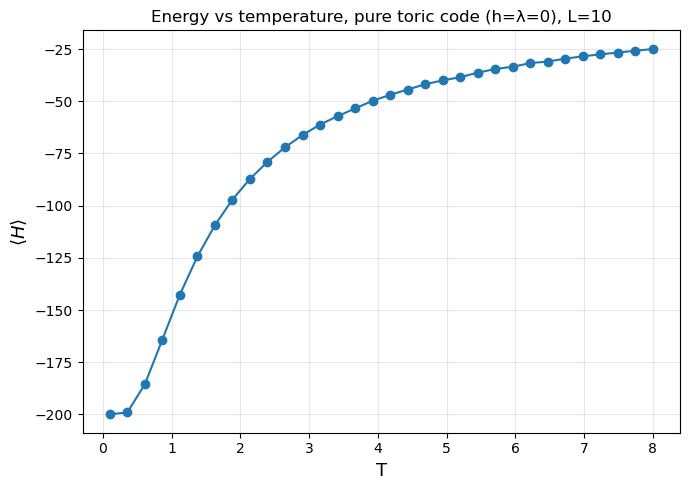

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(T, energy, yerr=energy_err, marker='o', capsize=3, color='C0')
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel(r'$\langle H \rangle$', fontsize=13)
ax.set_title('Energy vs temperature, pure toric code (h=λ=0), L=10', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('energy_vs_T.pdf', dpi=150)
plt.show()

# Heat capacity 

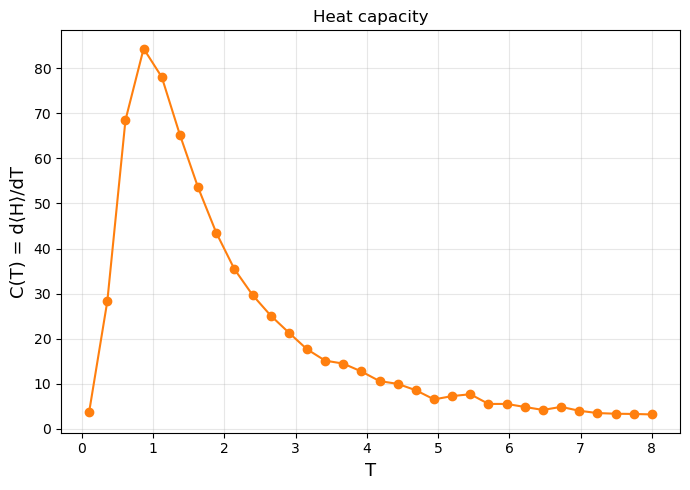

In [4]:
# C(T) = d<H>/dT — numerical derivative
# use central differences for interior, forward/backward at endpoints
C = np.gradient(energy, T)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T, C, marker='o', color='C1')
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel('C(T) = d⟨H⟩/dT', fontsize=13)
ax.set_title('Heat capacity', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('heat_capacity_vs_T.pdf', dpi=150)
plt.show()

# Thermal entrophy

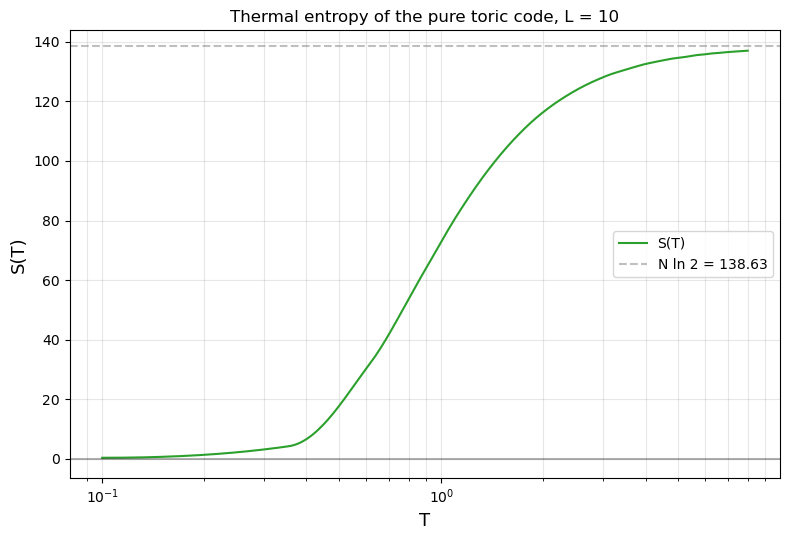

S(T_min = 0.100) = 0.2705
S(T_max = 8.00) = 137.0669


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# --- Method ---
# Thermal entropy via thermodynamic integration of the energy.
# Starting from the relation dS = dE/T and applying integration by parts:
#
#   S(T1) = S(T2) - [E(T2) - E(T1)] / T2 - ∫_{T1}^{T2} [E(T') - E(T1)] / T'^2 dT'
#
# Reference: S(T2) at high T from the high-temperature series expansion
#   S(T) ≈ N ln 2 - σ_H² / (2 T²) + O(1/T⁴)
# with σ_H² = J² N_plaq + μ² N_vert (variance of H at infinite T).
#
# Interpolation: PCHIP (shape-preserving cubic Hermite) through the E(T) data
# avoids the boundary overshoot of standard cubic splines.

# --- Interpolation of E(T) ---
order = np.argsort(T)
T_arr = T[order]
E_arr = energy[order]
pchip = PchipInterpolator(T_arr, E_arr)

T_dense = np.linspace(T_arr.min(), T_arr.max(), 1000)
E_dense = pchip(T_dense)

# --- Lattice and high-T reference ---
L_val   = 10
N_spins = 2 * L_val * L_val
N_plaq  = L_val * L_val
N_vert  = L_val * L_val
sigma_H_sq = N_plaq + N_vert        # for J = μ = 1

T2 = T_dense[-1]
E2 = E_dense[-1]
S2 = N_spins * np.log(2) - sigma_H_sq / (2 * T2**2)

# --- Thermodynamic integration ---
S_dense = np.zeros_like(T_dense)
for i, T1 in enumerate(T_dense):
    E1 = E_dense[i]
    Ts = T_dense[i:]
    Es = E_dense[i:]
    integrand = (Es - E1) / Ts**2
    integral  = np.trapezoid(integrand, Ts)
    S_dense[i] = S2 - (E2 - E1) / T2 - integral

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(T_dense, S_dense, '-', color='C2', label='S(T)')
ax.axhline(N_spins * np.log(2), color='gray', ls='--', alpha=0.5,
           label=f'N ln 2 = {N_spins * np.log(2):.2f}')
ax.axhline(0, color='black', alpha=0.3)
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel('S(T)', fontsize=13)
ax.set_title('Thermal entropy of the pure toric code, L = 10', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('entropy_vs_T.pdf', dpi=150)
plt.show()

print(f"S(T_min = {T_dense[0]:.3f}) = {S_dense[0]:.4f}")
print(f"S(T_max = {T_dense[-1]:.2f}) = {S_dense[-1]:.4f}")

# Scaling Analysis

In [14]:
import h5py, glob, os, re
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

results_root = os.path.expanduser('~/ParaToric/results')
t_files = sorted(glob.glob(f'{results_root}/T_sweep/L*/etc_T_sweep/lattice*/simulation_data.h5'))

data_T = {}
for f in t_files:
    m = re.search(r'_L=(\d+)_', f)
    L = int(m.group(1))
    with h5py.File(f, 'r') as h:
        T_raw = h['temperatures'][...]
        E_raw = h['energy_'][...]
    order = np.argsort(T_raw)
    data_T[L] = {'T': T_raw[order], 'E': E_raw[order]}

Ls = sorted(data_T.keys())
print(f"L values: {Ls}")

L values: [4, 6, 8, 10, 12]


# computing S for each

In [15]:
def compute_S(T_data, E_data, L):
    pchip = PchipInterpolator(T_data, E_data)
    T_dense = np.linspace(T_data.min(), T_data.max(), 1000)
    E_dense = pchip(T_dense)

    N_spins    = 2 * L * L
    sigma_H_sq = 2 * L * L

    T2 = T_dense[-1]
    E2 = E_dense[-1]
    S2 = N_spins * np.log(2) - sigma_H_sq / (2 * T2**2)

    S_dense = np.zeros_like(T_dense)
    for i, T1 in enumerate(T_dense):
        E1 = E_dense[i]
        Ts = T_dense[i:]
        Es = E_dense[i:]
        integrand = (Es - E1) / Ts**2
        integral  = np.trapezoid(integrand, Ts)
        S_dense[i] = S2 - (E2 - E1) / T2 - integral

    return T_dense, S_dense, N_spins

for L in Ls:
    T_d, S_d, N = compute_S(data_T[L]['T'], data_T[L]['E'], L)
    data_T[L]['T_dense'] = T_d
    data_T[L]['S_dense'] = S_d
    data_T[L]['N_spins'] = N

for L in Ls:
    print(f"L={L:2d}: N={data_T[L]['N_spins']:3d}, S(T_min)={data_T[L]['S_dense'][0]:8.4f}, S(T_max)={data_T[L]['S_dense'][-1]:8.4f}")

L= 4: N= 32, S(T_min)=  0.5070, S(T_max)= 21.9307
L= 6: N= 72, S(T_min)=  0.5130, S(T_max)= 49.3441
L= 8: N=128, S(T_min)=  0.1769, S(T_max)= 87.7228
L=10: N=200, S(T_min)=  0.2705, S(T_max)=137.0669
L=12: N=288, S(T_min)= -0.4166, S(T_max)=197.3764


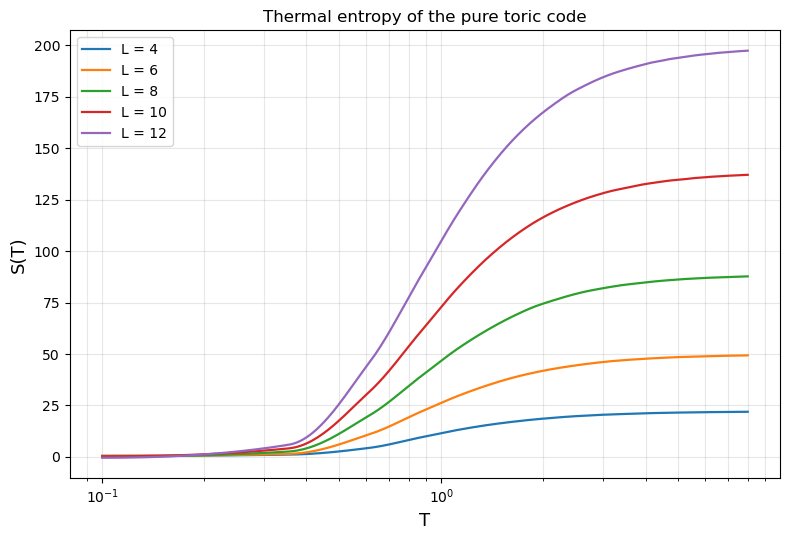

In [16]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for L in Ls:
    ax.plot(data_T[L]['T_dense'], data_T[L]['S_dense'], '-', label=f'L = {L}', linewidth=1.6)
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel('S(T)', fontsize=13)
ax.set_title('Thermal entropy of the pure toric code', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('entropy_vs_T_all_L.pdf', dpi=150)
plt.show()

# entrophy per spin

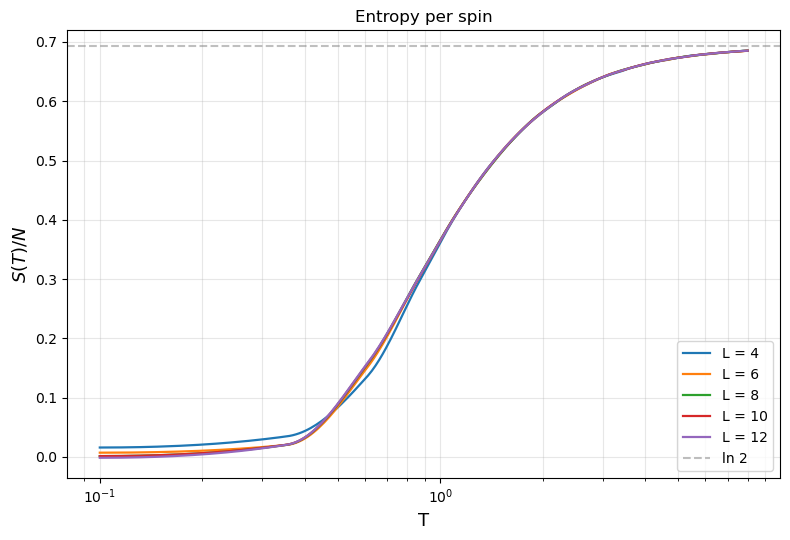

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for L in Ls:
    ax.plot(data_T[L]['T_dense'],
            data_T[L]['S_dense'] / data_T[L]['N_spins'],
            '-', label=f'L = {L}', linewidth=1.6)
ax.axhline(np.log(2), color='gray', ls='--', alpha=0.5, label='ln 2')
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel(r'$S(T) / N$', fontsize=13)
ax.set_title('Entropy per spin', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('entropy_per_spin_all_L.pdf', dpi=150)
plt.show()

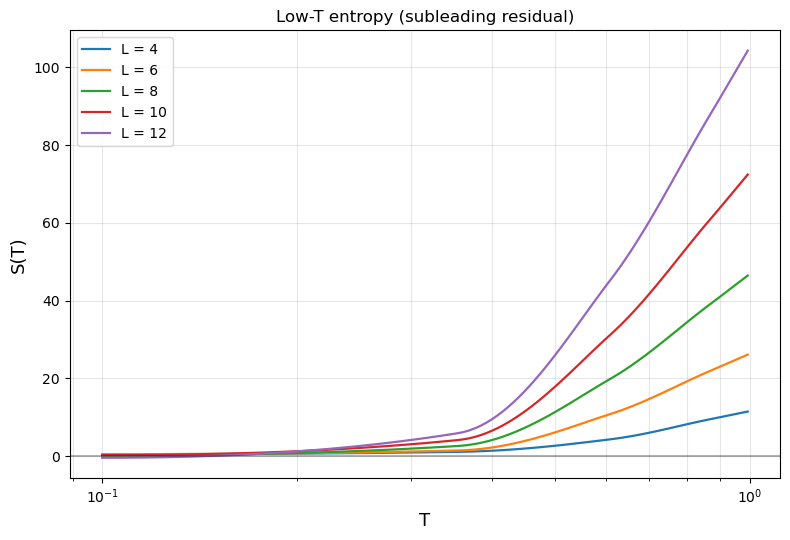


S(T_min) for each L:
  L =  4: S(T = 0.100) = 0.5070
  L =  6: S(T = 0.100) = 0.5130
  L =  8: S(T = 0.100) = 0.1769
  L = 10: S(T = 0.100) = 0.2705
  L = 12: S(T = 0.100) = -0.4166


In [18]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for L in Ls:
    mask = data_T[L]['T_dense'] < 1.0
    ax.plot(data_T[L]['T_dense'][mask], data_T[L]['S_dense'][mask],
            '-', label=f'L = {L}', linewidth=1.6)
ax.axhline(0, color='black', alpha=0.3)
ax.set_xlabel('T', fontsize=13)
ax.set_ylabel('S(T)', fontsize=13)
ax.set_title('Low-T entropy (subleading residual)', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('entropy_low_T_residual.pdf', dpi=150)
plt.show()

print("\nS(T_min) for each L:")
for L in Ls:
    print(f"  L = {L:2d}: S(T = {data_T[L]['T_dense'][0]:.3f}) = {data_T[L]['S_dense'][0]:.4f}")